# **Atividade Módulo 4 - Python para Preparação dos Dados**
### Base PRF 2025
### Enderson dos Santos Carvalho - FAP Análise de Dados 2026


## Sessão 1 - Abertura, ambiente de trabalho e primeira leitura da base
**Objetivo:** situar o módulo no CRISP-DM, montar o ambiente de trabalho e realizar a
primeira leitura crítica da base bruta da PRF.

Este módulo está na fase de **Preparação dos Dados** do CRISP-DM: revisita a Compreensão
dos Dados e prepara o terreno para Modelagem, Avaliação e Comunicação (Módulos 5, 6 e 7).

**Entrega oficial do módulo:** notebook executável + base analítica completa +
base modelável sem data leakage + README e decisões de tratamento.

### Bloco 1 - Preparação do ambiente de trabalho (Etapas 4 a 6)


In [9]:
# ETAPA 4 - Importar bibliotecas e configurar ambiente

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import unicodedata

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

'''
ETAPA 5 - Criar estrutura de pastas
- Separa dados brutos e tratados, organiza notebooks/sql/relatórios e evita sobrescrever o CSV/planilha original.)
'''

RAIZ = Path(".")
PASTAS = [
    "dados_brutos", "dados_tratados", "notebooks", "sql",
    "dashboards", "relatorios", "apresentacao", "logs"
]
for pasta in PASTAS:
    (RAIZ / pasta).mkdir(parents=True, exist_ok=True)

print("Pastas verificadas/criadas:")
for pasta in PASTAS:
    print("-", RAIZ / pasta)

'''
ETAPA 6 - Definir parâmetros do projeto
- Centraliza nomes de arquivos para facilitar mudança de caminho e evitar strings espalhadas pelo notebook.
'''
ARQUIVO_BRUTO = Path("dados_brutos/dados_abertos_prf-datatran2025.csv")
ARQUIVO_BASE_ANALITICA = Path("dados_tratados/base_analitica_prf_2025.csv")
ARQUIVO_BASE_MODELAVEL = Path("dados_tratados/base_modelavel_prf_2025.csv")
ARQUIVO_DICIONARIO = Path("dados_tratados/dicionario_variaveis_modulo4.csv")
ARQUIVO_DECISOES = Path("logs/decisoes_tratamento_modulo4.md")
ARQUIVO_README = Path("README.md")

SEPARADOR = ";"
ENCODING_ENTRADA = "latin1"     # usado apenas se o arquivo bruto for .csv
ENCODING_SAIDA = "utf-8-sig"    # usado na exportação das bases tratadas


Pastas verificadas/criadas:
- dados_brutos
- dados_tratados
- notebooks
- sql
- dashboards
- relatorios
- apresentacao
- logs


### Bloco 2 - Leitura e primeira inspeção da base (Etapas 7 a 10)

In [10]:
'''
ETAPA 7 - Ler a base da PRF com fallback de encoding
- Função que funciona tanto para .csv (separador ; com fallback de encoding) quanto para .xlsx (caso da base fornecida), evitando travar a aula por causa do formato do arquivo.
'''
def ler_base_prf(caminho, sep=";", encodings=("latin1", "utf-8", "utf-8-sig")):
    caminho = Path(caminho)
    if caminho.suffix.lower() in (".xlsx", ".xls"):
        print(f"Arquivo Excel detectado: {caminho.name}")
        return pd.read_excel(caminho)

    ultimo_erro = None
    for enc in encodings:
        try:
            print(f"Tentando leitura com encoding={enc}...")
            return pd.read_csv(caminho, sep=sep, encoding=enc, low_memory=False)
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou com {enc}: {erro}")
    raise ultimo_erro

df = ler_base_prf(ARQUIVO_BRUTO, sep=SEPARADOR)
df.head()

'''
ETAPA 8 - Padronizar nomes das colunas
- Minúsculas, sem acentos, underline, compatibilização de grafias.
# ============================================================
'''
def normalizar_nome_coluna(nome):
    nome = str(nome).strip().lower()
    nome = unicodedata.normalize("NFKD", nome).encode("ascii", "ignore").decode("utf-8")
    nome = nome.replace(" ", "_").replace("-", "_").replace("/", "_")
    while "__" in nome:
        nome = nome.replace("__", "_")
    return nome.strip("_")

df.columns = [normalizar_nome_coluna(c) for c in df.columns]

renomear = {"condicao_meteorologica": "condicao_metereologica"}
df = df.rename(columns={k: v for k, v in renomear.items() if k in df.columns})

print(df.columns.tolist())

'''
ETAPA 9 - Conferir colunas esperadas
- Valida a estrutura da base antes de transformar, evitando erro silencioso nos próximos passos.
'''
colunas_esperadas = [
    "data_inversa", "dia_semana", "horario", "uf", "br", "municipio",
    "causa_acidente", "tipo_acidente", "classificacao_acidente",
    "fase_dia", "condicao_metereologica", "tipo_pista", "tracado_via",
    "uso_solo", "pessoas", "mortos", "feridos_leves",
    "feridos_graves", "feridos", "veiculos"
]
faltantes = [c for c in colunas_esperadas if c not in df.columns]
print("Colunas faltantes:", faltantes)
if faltantes:
    print("Atenção: ajuste nomes ou confirme o dicionário oficial da PRF usado no arquivo.")
else:
    print("OK - todas as colunas esperadas estão presentes na base.")

'''
ETAPA 10 - Retrato inicial da base
- Dimensões, primeiras linhas e amostra aleatória para senso inicial.
'''
print("Dimensões:", df.shape)
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])
display(df.head())
display(df.sample(5, random_state=42))


Tentando leitura com encoding=latin1...
['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop']
Colunas faltantes: []
OK - todas as colunas esperadas estão presentes na base.
Dimensões: (72529, 30)
Linhas: 72529
Colunas: 30


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
0,652493,2025-01-01,quarta-feira,06:20:00,SP,116,225,GUARULHOS,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Pleno dia,Decrescente,Céu Claro,Múltipla,Reta;Declive,Sim,2,0,1,0,0,1,1,2,"-23,48586772","-46,54075317",SPRF-SP,DEL01-SP,UOP01-DEL01-SP
1,652519,2025-01-01,quarta-feira,07:50:00,CE,116,"546,2",PENAFORTE,Pista esburacada,Colisão frontal,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,6,1,1,0,1,4,1,6,"-7,812288","-39,08333306",SPRF-CE,DEL05-CE,UOP03-DEL05-CE
2,652522,2025-01-01,quarta-feira,08:45:00,PR,369,"88,2",CORNELIO PROCOPIO,Reação tardia ou ineficiente do condutor,Colisão traseira,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Dupla,Reta;Aclive,Sim,5,0,3,0,2,0,3,2,"-23,182565","-50,637228",SPRF-PR,DEL07-PR,UOP05-DEL07-PR
3,652544,2025-01-01,quarta-feira,11:00:00,PR,116,74,CAMPINA GRANDE DO SUL,Reação tardia ou ineficiente do condutor,Saída de leito carroçável,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Dupla,Reta,Não,5,0,1,0,4,0,1,2,"-25,36517687","-49,04223028",SPRF-PR,DEL01-PR,UOP02-DEL01-PR
4,652549,2025-01-01,quarta-feira,09:30:00,MG,251,471,FRANCISCO SA,Velocidade Incompatível,Colisão frontal,Com Vítimas Feridas,Pleno dia,Decrescente,Chuva,Simples,Curva;Declive,Não,5,0,1,1,1,2,2,4,"-16,46801304","-43,43121303",SPRF-MG,DEL12-MG,UOP01-DEL12-MG


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop
6366,691804,2025-03-15,sábado,12:30:00,ES,101,67,SAO MATEUS,Condutor desrespeitou a iluminação vermelha do...,Colisão transversal,Com Vítimas Feridas,Pleno dia,Crescente,Sol,Simples,Rotatória,Sim,4,0,0,2,1,2,2,4,"-18,72802869","-39,85997558",SPRF-ES,DEL04-ES,UOP02-DEL04-ES
9405,704622,2025-07-13,domingo,22:30:00,PE,423,"74,1",JUPI,Condutor deixou de manter distância do veículo...,Colisão traseira,Sem Vítimas,Plena Noite,Decrescente,Céu Claro,Simples,Aclive;Reta,Sim,2,0,0,0,2,0,0,2,"-8,7160879","-36,4219923",SPRF-PE,DEL03-PE,UOP01-DEL03-PE
26102,663260,2025-02-23,domingo,18:10:00,BA,242,231,ITABERABA,Animais na Pista,Atropelamento de Animal,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Reta,Sim,1,0,1,0,0,0,1,1,"-12,511706","-40,324247",SPRF-BA,DEL06-BA,UOP02-DEL06-BA
28616,667036,2025-03-13,quinta-feira,19:55:00,DF,20,"9,9",BRASILIA,Reação tardia ou ineficiente do condutor,Engavetamento,Com Vítimas Feridas,Plena Noite,Crescente,Céu Claro,Dupla,Reta,Não,6,0,4,0,2,0,4,3,"-15,6502715","-47,7763723",SPRF-DF,DEL02-DF,UOP01-DEL02-DF
1696,660353,2025-02-09,domingo,19:05:00,MA,222,665,ACAILANDIA,Pedestre andava na pista,Atropelamento de Pedestre,Com Vítimas Feridas,Plena Noite,Decrescente,Céu Claro,Simples,Declive,Não,3,0,1,1,0,1,2,3,"-4,89367779","-47,38426513",SPRF-MA,DEL04-MA,UOP03-DEL04-MA


### Bloco 3 - Diagnóstico de qualidade dos dados (Etapas 11 a 14)

In [11]:
# ETAPA 11 - Tipos de dados e memória
df.info(memory_usage="deep")

resumo_tipos = (
    df.dtypes.astype(str)
    .value_counts()
    .rename_axis("tipo")
    .reset_index(name="qtd_colunas")
)
display(resumo_tipos)

'''
ETAPA 12 - Diagnóstico de valores ausentes
- Não confundir nulo com zero: zero é informação válida em campos como "mortos".
'''
nulos = pd.DataFrame({
    "qtd_nulos": df.isna().sum(),
    "perc_nulos": df.isna().mean() * 100
}).sort_values("perc_nulos", ascending=False)
display(nulos[nulos["qtd_nulos"] > 0])

# ETAPA 13 - Diagnóstico e remoção de duplicidades
qtd_duplicadas = df.duplicated().sum()
print("Duplicidades exatas:", qtd_duplicadas)
if qtd_duplicadas > 0:
    df = df.drop_duplicates().copy()
    print("Duplicidades removidas. Nova dimensão:", df.shape)
else:
    print("Nenhuma duplicidade exata encontrada - base já vem sem duplicatas.")

'''
ETAPA 14 - Cardinalidade das categorias
- Município tende a ter alta cardinalidade; causa e tipo exigem cuidado especial.
'''
categoricas = df.select_dtypes(include="object").columns
if len(categoricas) == 0:
    categoricas = df.select_dtypes(include="string").columns

cardinalidade = (
    df[categoricas]
    .nunique(dropna=True)
    .sort_values(ascending=False)
    .reset_index()
)
cardinalidade.columns = ["variavel", "qtd_categorias"]
display(cardinalidade.head(30))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72529 entries, 0 to 72528
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   id                      72529 non-null  int64 
 1   data_inversa            72529 non-null  object
 2   dia_semana              72529 non-null  object
 3   horario                 72529 non-null  object
 4   uf                      72529 non-null  object
 5   br                      72529 non-null  int64 
 6   km                      72529 non-null  object
 7   municipio               72529 non-null  object
 8   causa_acidente          72529 non-null  object
 9   tipo_acidente           72529 non-null  object
 10  classificacao_acidente  72528 non-null  object
 11  fase_dia                72529 non-null  object
 12  sentido_via             72529 non-null  object
 13  condicao_metereologica  72529 non-null  object
 14  tipo_pista              72529 non-null  object
 15  tr

,tipo,qtd_colunas
0,object,20
1,int64,10


,qtd_nulos,perc_nulos
uop,38,0.052393
delegacia,22,0.030333
regional,2,0.002758
classificacao_acidente,1,0.001379


Duplicidades exatas: 0
Nenhuma duplicidade exata encontrada - base já vem sem duplicatas.


,variavel,qtd_categorias
0,latitude,69294
1,longitude,69237
2,km,7655
3,municipio,1844
4,horario,1412
5,tracado_via,605
6,uop,395
7,data_inversa,365
8,delegacia,153
9,causa_acidente,69


## Sessão 2 - Transformações e variáveis derivadas
**Objetivo:** converter tipos, tratar datas e horários, padronizar textos e tratar nulos
para deixar a base pronta para receber o alvo.

### Bloco 4 - Transformações e criação de variáveis derivadas (Etapas 15 a 21)


In [12]:
'''
ETAPA 15 - Converter colunas numéricas
- Com errors= "coerce", entradas inválidas viram nulo (na base fornecida essas colunas já vêm como int64/float64, então esta etapa funciona como uma "garantia" e não deve gerar novos nulos).
'''
colunas_numericas = [
    "br", "km", "pessoas", "mortos", "feridos", "feridos_leves",
    "feridos_graves", "ilesos", "ignorados", "veiculos"
]
if "km" in df.columns:
    df["km"] = df["km"].astype(str).str.replace(",", ".", regex=False)

for coluna in colunas_numericas:
    if coluna in df.columns:
      df[coluna] = pd.to_numeric(df[coluna], errors="coerce")

print(df[[c for c in colunas_numericas if c in df.columns]].dtypes)

'''
ETAPA 16 - Tratar datas e criar variáveis temporais
- ano, mês, trimestre, dia da semana numérico e fim de semana
'''
df["data_inversa"] = pd.to_datetime(df["data_inversa"], errors="coerce")
df["ano"] = df["data_inversa"].dt.year
df["mes"] = df["data_inversa"].dt.month
df["trimestre"] = df["data_inversa"].dt.quarter
df["dia_semana_num"] = df["data_inversa"].dt.dayofweek
df["fim_de_semana"] = df["dia_semana_num"].isin([5, 6]).astype(int)

display(df[["data_inversa", "ano", "mes", "trimestre", "dia_semana_num", "fim_de_semana"]].head())

'''
ETAPA 17 - Tratar horário e criar turno
- Extrai a hora, classifica madrugada/manhã/tarde/noite e trata horários inválidos como IGNORADO
-"horario" vem como datetime.time;
- .astype(str) converte para "HH:MM:SS" e o parser continua funcionando normalmente
'''
horario_limpo = df["horario"].astype(str).str.strip()
df["hora"] = pd.to_datetime(horario_limpo, format="%H:%M:%S", errors="coerce").dt.hour

# Tentativa alternativa para arquivos com HH:MM
faltou_hora = df["hora"].isna()
if faltou_hora.any():
    df.loc[faltou_hora, "hora"] = pd.to_datetime(
        horario_limpo[faltou_hora], format="%H:%M", errors="coerce"
    ).dt.hour

def classificar_turno(hora):
    if pd.isna(hora):
        return "IGNORADO"
    if 0 <= hora <= 5:
        return "MADRUGADA"
    if 6 <= hora <= 11:
        return "MANHA"
    if 12 <= hora <= 17:
        return "TARDE"
    return "NOITE"

df["turno"] = df["hora"].apply(classificar_turno)
display(df[["horario", "hora", "turno"]].head())

'''
ETAPA 18 - Criar faixa horária
- Blocos de 3 horas, reduz granularidade excessiva do horário.
'''
def criar_faixa_horaria(hora):
    if pd.isna(hora):
        return "IGNORADO"
    inicio = int(hora // 3) * 3
    fim = inicio + 2
    return f"{inicio:02d}h-{fim:02d}h"

df["faixa_horaria"] = df["hora"].apply(criar_faixa_horaria)
display(df["faixa_horaria"].value_counts(dropna=False).sort_index())

'''
ETAPA 19 - Padronizar textos
- Remove espaços, uniformiza em maiúsculas e transforma vazios em nulos para evitar categorias artificiais.
'''
colunas_texto = df.select_dtypes(include=["object", "string"]).columns
for coluna in colunas_texto:
    df[coluna] = (
        df[coluna]
        .astype("string")
        .str.strip()
        .str.upper()
    )
    df[coluna] = df[coluna].replace({"": pd.NA, "NAN": pd.NA, "NONE": pd.NA, "NULL": pd.NA})

print("Colunas textuais padronizadas:", len(colunas_texto))

'''
ETAPA 20 - Tratar nulos categóricos
- Usa IGNORADO em campos explicativos para não perder linhas e preservar a informação de ausência.
'''
categoricas_importantes = [
    "uf", "municipio", "causa_acidente", "tipo_acidente", "fase_dia",
    "condicao_metereologica", "tipo_pista", "tracado_via", "uso_solo",
    "classificacao_acidente", "dia_semana"
]
for coluna in categoricas_importantes:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna("IGNORADO")

print(df[categoricas_importantes].isna().sum().sort_values(ascending=False))

#ETAPA 21 - Tratar nulos numéricos de contagem Zero como hipótese operacional conservadora para contagens de vítimas.

contagens_vitimas = ["mortos", "feridos", "feridos_leves", "feridos_graves", "pessoas", "veiculos"]
for coluna in contagens_vitimas:
    if coluna in df.columns:
        df[coluna] = df[coluna].fillna(0)

print(df[[c for c in contagens_vitimas if c in df.columns]].isna().sum())


br                  int64
km                float64
pessoas             int64
mortos              int64
feridos             int64
feridos_leves       int64
feridos_graves      int64
ilesos              int64
ignorados           int64
veiculos            int64
dtype: object


,data_inversa,ano,mes,trimestre,dia_semana_num,fim_de_semana
0,2025-01-01,2025,1,1,2,0
1,2025-01-01,2025,1,1,2,0
2,2025-01-01,2025,1,1,2,0
3,2025-01-01,2025,1,1,2,0
4,2025-01-01,2025,1,1,2,0


,horario,hora,turno
0,06:20:00,6,MANHA
1,07:50:00,7,MANHA
2,08:45:00,8,MANHA
3,11:00:00,11,MANHA
4,09:30:00,9,MANHA


,count
faixa_horaria,
00h-02h,3959
03h-05h,4948
06h-08h,11517
09h-11h,9342
12h-14h,9678
15h-17h,12624
18h-20h,13473
21h-23h,6988


Colunas textuais padronizadas: 20
uf                        0
municipio                 0
causa_acidente            0
tipo_acidente             0
fase_dia                  0
condicao_metereologica    0
tipo_pista                0
tracado_via               0
uso_solo                  0
classificacao_acidente    0
dia_semana                0
dtype: int64
mortos            0
feridos           0
feridos_leves     0
feridos_graves    0
pessoas           0
veiculos          0
dtype: int64


## Sessão 3 - Variável-alvo e indicadores de gravidade
**Objetivo:** construir e validar a variável-alvo `acidente_fatal`, criar indicadores
derivados e realizar checagens de consistência.

### Bloco 5 - Variável-alvo e indicadores de gravidade (Etapas 22 a 29)


,acidente_fatal,qtd,perc
0,0,67319,92.816666
1,1,5210,7.183334


Violações da regra do alvo: 0


,mortos,feridos_leves,feridos_graves,total_vitimas,indice_gravidade
0,0,1,0,1,1
1,1,1,0,2,4
2,0,3,0,3,3
3,0,1,0,1,1
4,0,1,1,2,3


,uf,municipio,br,br_formatada,chave_localidade
0,SP,GUARULHOS,116,BR-116,SP_GUARULHOS_BR-116
1,CE,PENAFORTE,116,BR-116,CE_PENAFORTE_BR-116
2,PR,CORNELIO PROCOPIO,369,BR-369,PR_CORNELIO PROCOPIO_BR-369
3,PR,CAMPINA GRANDE DO SUL,116,BR-116,PR_CAMPINA GRANDE DO SUL_BR-116
4,MG,FRANCISCO SA,251,BR-251,MG_FRANCISCO SA_BR-251


,causa_acidente,qtd
0,AUSÊNCIA DE REAÇÃO DO CONDUTOR,11469
1,REAÇÃO TARDIA OU INEFICIENTE DO CONDUTOR,10799
2,ACESSAR A VIA SEM OBSERVAR A PRESENÇA DOS OUTR...,7097
3,CONDUTOR DEIXOU DE MANTER DISTÂNCIA DO VEÍCULO...,4413
4,VELOCIDADE INCOMPATÍVEL,4088
5,MANOBRA DE MUDANÇA DE FAIXA,4016
6,INGESTÃO DE ÁLCOOL PELO CONDUTOR,3685
7,DEMAIS FALHAS MECÂNICAS OU ELÉTRICAS,3385
8,TRANSITAR NA CONTRAMÃO,2475
9,CONDUTOR DORMINDO,2116


,tipo_acidente,qtd
0,COLISÃO TRASEIRA,14360
1,SAÍDA DE LEITO CARROÇÁVEL,10209
2,COLISÃO TRANSVERSAL,9306
3,COLISÃO LATERAL MESMO SENTIDO,7885
4,TOMBAMENTO,6351
5,COLISÃO COM OBJETO,5109
6,COLISÃO FRONTAL,4739
7,QUEDA DE OCUPANTE DE VEÍCULO,3450
8,ATROPELAMENTO DE PEDESTRE,3057
9,COLISÃO LATERAL SENTIDO OPOSTO,2152


,tipo_acidente,qtd_acidentes,qtd_fatais,taxa_fatal
1,ATROPELAMENTO DE PEDESTRE,3057,902,0.295061
4,COLISÃO FRONTAL,4739,1396,0.294577
6,COLISÃO LATERAL SENTIDO OPOSTO,2152,212,0.098513
11,EVENTOS ATÍPICOS,287,23,0.080139
0,ATROPELAMENTO DE ANIMAL,1133,68,0.060018
14,SAÍDA DE LEITO CARROÇÁVEL,10209,605,0.059261
3,COLISÃO COM OBJETO,5109,297,0.058133
2,CAPOTAMENTO,1373,63,0.045885
7,COLISÃO TRANSVERSAL,9306,427,0.045884
8,COLISÃO TRASEIRA,14360,619,0.043106


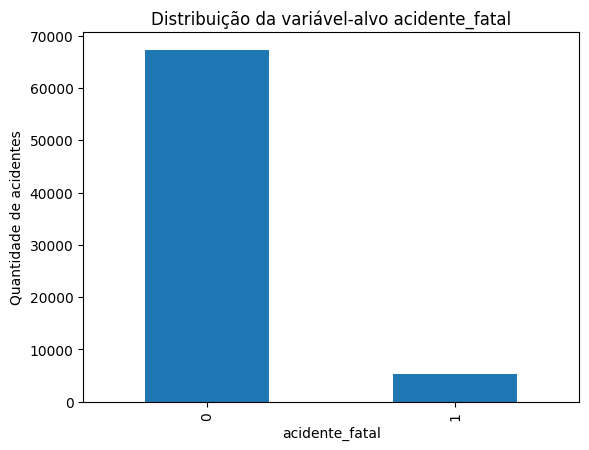

In [13]:
'''
ETAPA 22 - Criar variável-alvo acidente_fatal
- 1 quando mortos >= 1; 0 quando mortos = 0. Centro do problema binário.
'''
df["acidente_fatal"] = np.where(df["mortos"] >= 1, 1, 0)

validacao_alvo = (
    df["acidente_fatal"]
    .value_counts(dropna=False)
    .rename_axis("acidente_fatal")
    .reset_index(name="qtd")
)
validacao_alvo["perc"] = validacao_alvo["qtd"] / validacao_alvo["qtd"].sum() * 100
display(validacao_alvo)

'''ETAPA 23 - Validar logicamente o alvo
- Testa a regra, detecta inversões e nulos indevidos com assert.
'''
violacoes = df.loc[
    ((df["mortos"] >= 1) & (df["acidente_fatal"] != 1)) |
    ((df["mortos"] == 0) & (df["acidente_fatal"] != 0))
]
print("Violações da regra do alvo:", len(violacoes))
assert len(violacoes) == 0, "Há erro na criação de acidente_fatal."

'''ETAPA 24 - Criar indicadores de gravidade
- total_vitimas, acidente_grave e indice_gravidade tem uso para a análise.
'''
df["total_vitimas"] = df["mortos"] + df["feridos_leves"] + df["feridos_graves"]
df["acidente_grave"] = np.where(
    (df["mortos"] >= 1) | (df["feridos_graves"] >= 1), 1, 0
)
df["indice_gravidade"] = (
    df["mortos"] * 3
    + df["feridos_graves"] * 2
    + df["feridos_leves"]
)
display(df[["mortos", "feridos_leves", "feridos_graves", "total_vitimas", "indice_gravidade"]].head())

'''
ETAPA 25 - Criar BR formatada e chave de localidade
- Facilita filtros e agrupamentos.
'''
def formatar_br(valor):
    if pd.isna(valor) or valor == 0:
        return "BR-IGNORADA"
    return f"BR-{int(valor):03d}"

df["br_formatada"] = df["br"].apply(formatar_br)
df["chave_localidade"] = (
    df["uf"].astype(str) + "_" +
    df["municipio"].astype(str) + "_" +
    df["br_formatada"].astype(str)
)
display(df[["uf", "municipio", "br", "br_formatada", "chave_localidade"]].head())

# ETAPA 26 - Checagens rápidas após transformação
checagens = {
    "linhas": len(df),
    "colunas": df.shape[1],
    "acidentes_fatais": int(df["acidente_fatal"].sum()),
    "taxa_fatalidade": float(df["acidente_fatal"].mean()),
    "total_mortos": int(df["mortos"].sum()),
    "total_feridos": int(df["feridos"].sum()) if "feridos" in df.columns else None,
}
checagens

# ETAPA 27 - Ranking rápido de categorias
def ranking_categoria(base, coluna, n=10):
    return (
        base[coluna]
        .value_counts(dropna=False)
        .head(n)
        .rename_axis(coluna)
        .reset_index(name="qtd")
    )

display(ranking_categoria(df, "causa_acidente", 10))
display(ranking_categoria(df, "tipo_acidente", 10))

'''
ETAPA 28 - Taxa fatal por categoria
- Proporção (risco), não apenas frequência; filtro por mínimo de registros evita subgrupos minúsculos e instáveis.
'''
def taxa_fatal_por_categoria(base, coluna, min_registros=30):
    tab = base.groupby(coluna).agg(
        qtd_acidentes=("acidente_fatal", "size"),
        qtd_fatais=("acidente_fatal", "sum"),
        taxa_fatal=("acidente_fatal", "mean")
    ).reset_index()
    tab = tab[tab["qtd_acidentes"] >= min_registros]
    return tab.sort_values("taxa_fatal", ascending=False)

display(taxa_fatal_por_categoria(df, "tipo_acidente", min_registros=30).head(10))

'''ETAPA 29 - Gráfico simples de conferência
- Controle de qualidade da preparação (não substitui a EDA formal)
'''
ax = df["acidente_fatal"].value_counts().sort_index().plot(kind="bar")
ax.set_title("Distribuição da variável-alvo acidente_fatal")
ax.set_xlabel("acidente_fatal")
ax.set_ylabel("Quantidade de acidentes")
plt.show()


## Sessão 4 - Construção das bases finais e documentação
**Objetivo:** separar a base analítica da base modelável, eliminar data leakage, exportar
os arquivos finais e documentar as decisões do projeto.

### Bloco 6 - Construção das duas bases (Etapas 30 a 37)

- **Base analítica completa**: usada para EDA (Módulo 5) e Power BI (Módulo 6). Pode conter
  `mortos`, `feridos` e indicadores derivados de gravidade.
- **Base modelável**: usada na árvore de decisão (Módulo 7). Apenas variáveis explicativas
  pré-acidente + o alvo `acidente_fatal`. Exclui qualquer variável derivada do desfecho.


In [14]:
'''
ETAPA 31 - Gerar base analítica completa
- Cópia da base tratada, preserva variáveis descritivas e indicadores de gravidade.
'''
base_analitica = df.copy()
print("Base analítica:", base_analitica.shape)
print("Colunas:", base_analitica.columns.tolist())

'''ETAPA 33 - Selecionar variáveis modeláveis
- UF, BR, município, tempo/turno, causa/tipo/pista/clima/traçado e o alvo acidente_fatal.
'''
variaveis_modelaveis = [
    "uf", "br_formatada", "municipio", "mes", "trimestre",
    "dia_semana", "dia_semana_num", "fim_de_semana",
    "hora", "faixa_horaria", "turno", "fase_dia",
    "causa_acidente", "tipo_acidente", "condicao_metereologica",
    "tipo_pista", "tracado_via", "uso_solo",
    "acidente_fatal"
]
variaveis_modelaveis = [c for c in variaveis_modelaveis if c in df.columns]
base_modelavel = df[variaveis_modelaveis].copy()
print("Base modelável:", base_modelavel.shape)

'''
ETAPA 34 - Verificar data leakage
- mortos, feridos, total_vitimas, indice_gravidade, acidente_grave e classificacao_acidente ficam FORA da base modelável.
'''
variaveis_proibidas = [
    "mortos", "feridos", "feridos_leves", "feridos_graves",
    "total_vitimas", "indice_gravidade", "acidente_grave",
    "classificacao_acidente"
]

def verificar_data_leakage(base, proibidas):
    presentes = [c for c in proibidas if c in base.columns]
    if presentes:
        raise ValueError(f"Data leakage detectado: {presentes}")
    return "OK - nenhuma variável proibida encontrada."

print(verificar_data_leakage(base_modelavel, variaveis_proibidas))

'''ETAPA 35 - Tratamento final de nulos na base modelável
- Categóricas: IGNORADO. Numéricas: -1. Alvo preservado sem alteração.
'''
for coluna in base_modelavel.columns:
    if coluna == "acidente_fatal":
        continue
    if base_modelavel[coluna].dtype == "object" or str(base_modelavel[coluna].dtype) == "string":
        base_modelavel[coluna] = base_modelavel[coluna].fillna("IGNORADO")
    else:
        base_modelavel[coluna] = base_modelavel[coluna].fillna(-1)

print(base_modelavel.isna().sum().sort_values(ascending=False).head())

'''
ETAPA 36 - Exportar bases tratadas
- CSV em dados_tratados/, separador ; , utf-8-sig, sem sobrescrever os dados brutos.
'''
base_analitica.to_csv(ARQUIVO_BASE_ANALITICA, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
base_modelavel.to_csv(ARQUIVO_BASE_MODELAVEL, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Arquivos exportados:")
print("-", ARQUIVO_BASE_ANALITICA)
print("-", ARQUIVO_BASE_MODELAVEL)

'''
ETAPA 37 - Reabrir arquivos exportados
- Validação pós-exportação obrigatória: confere dimensões e legibilidade, detecta erro de encoding antes da entrega.
'''
valid_analitica = pd.read_csv(ARQUIVO_BASE_ANALITICA, sep=SEPARADOR, encoding=ENCODING_SAIDA)
valid_modelavel = pd.read_csv(ARQUIVO_BASE_MODELAVEL, sep=SEPARADOR, encoding=ENCODING_SAIDA)

print("Analítica reaberta:", valid_analitica.shape)
print("Modelável reaberta:", valid_modelavel.shape)
assert len(valid_analitica) == len(base_analitica)
assert len(valid_modelavel) == len(base_modelavel)
print("Validação pós-exportação: OK")


Base analítica: (72529, 44)
Colunas: ['id', 'data_inversa', 'dia_semana', 'horario', 'uf', 'br', 'km', 'municipio', 'causa_acidente', 'tipo_acidente', 'classificacao_acidente', 'fase_dia', 'sentido_via', 'condicao_metereologica', 'tipo_pista', 'tracado_via', 'uso_solo', 'pessoas', 'mortos', 'feridos_leves', 'feridos_graves', 'ilesos', 'ignorados', 'feridos', 'veiculos', 'latitude', 'longitude', 'regional', 'delegacia', 'uop', 'ano', 'mes', 'trimestre', 'dia_semana_num', 'fim_de_semana', 'hora', 'turno', 'faixa_horaria', 'acidente_fatal', 'total_vitimas', 'acidente_grave', 'indice_gravidade', 'br_formatada', 'chave_localidade']
Base modelável: (72529, 19)
OK - nenhuma variável proibida encontrada.
uf              0
br_formatada    0
municipio       0
mes             0
trimestre       0
dtype: int64
Arquivos exportados:
- dados_tratados/base_analitica_prf_2025.csv
- dados_tratados/base_modelavel_prf_2025.csv
Analítica reaberta: (72529, 44)
Modelável reaberta: (72529, 19)
Validação pós-ex

### Bloco 7 - Documentação do projeto (Etapas 38 a 41)

In [15]:
# ETAPA 38 - Gerar dicionário das variáveis criadas
linhas_dic = [
    {"variavel": "acidente_fatal", "descricao": "1 se mortos >= 1; 0 se mortos = 0", "uso": "alvo"},
    {"variavel": "total_vitimas", "descricao": "mortos + feridos leves + feridos graves", "uso": "analise/dashboard"},
    {"variavel": "indice_gravidade", "descricao": "mortos*3 + feridos_graves*2 + feridos_leves", "uso": "analise/dashboard"},
    {"variavel": "br_formatada", "descricao": "BR padronizada no formato BR-000", "uso": "analise/modelagem"},
    {"variavel": "chave_localidade", "descricao": "UF + município + BR formatada", "uso": "analise/dashboard"},
]
dicionario = pd.DataFrame(linhas_dic)
dicionario.to_csv(ARQUIVO_DICIONARIO, index=False, sep=SEPARADOR, encoding=ENCODING_SAIDA)
display(dicionario)

# ETAPA 39 - Registrar decisões de tratamento
texto_decisoes = f"""# Decisões de tratamento - Módulo 4

Data de geração: {datetime.now().strftime('%Y-%m-%d %H:%M')}

## Principais decisões
- Nomes de colunas padronizados para minúsculas, sem acentos e com underline.
- Colunas numéricas convertidas com `pd.to_numeric(errors='coerce')`.
- Datas convertidas com `pd.to_datetime(errors='coerce')`.
- Categorias ausentes relevantes preenchidas como IGNORADO.
- Variável-alvo: acidente_fatal = 1 quando mortos >= 1.
- Base modelável exclui variáveis derivadas do desfecho.
- Arquivo bruto lido como .xlsx (ajuste em relação ao roteiro original, que previa .csv).

## Arquivos gerados
- {ARQUIVO_BASE_ANALITICA}
- {ARQUIVO_BASE_MODELAVEL}
- {ARQUIVO_DICIONARIO}
"""
ARQUIVO_DECISOES.write_text(texto_decisoes, encoding="utf-8")
print(ARQUIVO_DECISOES)

# ETAPA 40 - Criar README do projeto
readme = f"""# Projeto PRF 2025 - Preparação dos Dados (Módulo 4)

Pipeline de preparação de dados dos acidentes registrados pela Polícia Rodoviária Federal
(PRF) em 2025, agrupados por ocorrência. Este projeto transforma o arquivo bruto da PRF em
dois ativos analíticos reprodutíveis: uma **base analítica completa** (para EDA e Power BI)
e uma **base modelável sem data leakage** (para a árvore de decisão).

---

## 1. Objetivo

Preparar os dados de acidentes da PRF 2025 para:
- Análise Exploratória de Dados (Módulo 5);
- Dashboard no Power BI (Módulo 6);
- Árvore de decisão explicável (Módulo 7).

O projeto segue a fase de **Preparação dos Dados** do CRISP-DM, revisitando a Compreensão
dos Dados e deixando a base pronta para Modelagem, Avaliação e Comunicação.

---

## 2. Variável-alvo

`acidente_fatal`:
- `1` quando `mortos >= 1`
- `0` quando `mortos = 0`

Validada com teste lógico (`assert`) garantindo zero violações da regra antes da exportação.

---

## 3. Fonte de dados

- **Arquivo:** `dados_abertos_prf-datatran2025.csv`
- **Origem:** dados abertos da PRF, acidentes de 2025 agrupados por ocorrência.
- **Formato:** CSV com separador `;`, encoding `latin1` (ISO-8859-1), campos entre aspas.
- **Volume:** 72.529 linhas × 30 colunas na leitura bruta.
- **Particularidade:** os campos `km`, `latitude` e `longitude` usam vírgula como separador
  decimal (padrão brasileiro) - são convertidos para ponto antes da conversão numérica.

O arquivo bruto **não é versionado nem alterado**; toda transformação gera novos arquivos em
`dados_tratados/`.

---

## 4. Requisitos para rodar o notebook

### 4.1. Ambiente
- Google Colab (recomendado) ou Jupyter local com Python ≥ 3.9.
- Não é necessário GPU nem hardware especial - o processamento é feito inteiramente com
  `pandas` em memória (a base cabe tranquilamente em RAM padrão do Colab).

### 4.2. Bibliotecas utilizadas

| Biblioteca | Uso no projeto | Já vem no Colab? |
|---|---|---|
| `pandas` | Leitura, limpeza, transformação e exportação das bases | sim |
| `numpy` | Regras condicionais vetorizadas (`np.where`) para alvo e indicadores | sim |
| `matplotlib` | Gráfico de conferência da distribuição do alvo | sim |
| `pathlib` (stdlib) | Caminhos reprodutíveis entre sistemas operacionais | sim (padrão do Python) |
| `datetime` (stdlib) | Timestamp do log de decisões | sim (padrão do Python) |
| `unicodedata` (stdlib) | Remoção de acentos na padronização de nomes de colunas | sim (padrão do Python) |

Nenhuma instalação extra é necessária - todas as bibliotecas já vêm pré-instaladas no
Google Colab. Se for rodar localmente, basta:

```bash
pip install pandas numpy matplotlib
```

### 4.3. Arquivo de entrada
Antes de rodar, faça o upload do `dados_abertos_prf-datatran2025.csv` para a pasta
`dados_brutos/` (no Colab: ícone de pasta na lateral esquerda → clique com o botão direito
em `dados_brutos` → *Upload*).

---

## 5. Estrutura de pastas

```
.
├── dados_brutos/        # arquivo original da PRF - nunca é sobrescrito
├── dados_tratados/       # bases exportadas (analítica, modelável, dicionário)
├── notebooks/            # notebook do módulo
├── sql/                  # reservado para consultas futuras
├── dashboards/           # reservado para o Módulo 6 (Power BI)
├── relatorios/           # reservado para relatórios de apoio
├── apresentacao/         # reservado para material de apresentação
├── logs/                 # log de decisões de tratamento
└── README.md             # este arquivo
```

Essa estrutura é criada automaticamente pela primeira célula de código do notebook - não é
preciso criar nada manualmente.

---

## 6. Como executar

1. Abra o notebook `Modulo4_PRF_Preparacao_Dados.ipynb` no Google Colab.
2. Rode a célula que cria a estrutura de pastas.
3. Faça o upload de `dados_abertos_prf-datatran2025.csv` em `dados_brutos/`.
4. Execute as células em ordem, de cima para baixo (Kernel → Reiniciar e executar tudo,
   antes da entrega final, para garantir reprodutibilidade).
5. Ao final, confira o **checklist de saída** (seção 9 abaixo) - todos os itens devem
   retornar `True`/`OK`.

---

## 7. Principais decisões de tratamento

| Decisão | Regra adotada |
|---|---|
| Nomes de colunas | minúsculas, sem acento, `snake_case` |
| `km`, `latitude`, `longitude` | vírgula decimal trocada por ponto antes de `pd.to_numeric` |
| Colunas numéricas | `pd.to_numeric(errors="coerce")` |
| Datas | `pd.to_datetime(errors="coerce")` |
| Categorias ausentes relevantes | preenchidas como `"IGNORADO"` |
| Contagens de vítimas ausentes | preenchidas como `0` (hipótese operacional conservadora) |
| Duplicidade | remoção apenas de duplicidade exata (`df.duplicated()`) |
| Alvo | `acidente_fatal = 1` quando `mortos >= 1`, validado com `assert` |
| Separador de exportação | `;` (padrão da base PRF) |
| Encoding de exportação | `utf-8-sig` (compatível com Excel/Power BI, evita erro de acentuação) |

O detalhamento completo, com data e hora de geração, fica registrado automaticamente em
`logs/decisoes_tratamento_modulo4.md` a cada execução.

---

## 8. Bases geradas

- **`dados_tratados/base_analitica_prf_2025.csv`** - base completa para EDA e Power BI.
  Contém `mortos`, `feridos` e os indicadores de gravidade (`total_vitimas`,
  `indice_gravidade`, `acidente_grave`).
- **`dados_tratados/base_modelavel_prf_2025.csv`** - base para modelagem (árvore de
  decisão). Contém apenas variáveis explicativas pré-acidente + o alvo `acidente_fatal`.
  **Não contém** nenhuma variável derivada do desfecho.
- **`dados_tratados/dicionario_variaveis_modulo4.csv`** - dicionário das principais
  variáveis criadas no módulo (nome, descrição, uso previsto).

### Variáveis proibidas na base modelável (checadas por `verificar_data_leakage`)
`mortos`, `feridos`, `feridos_leves`, `feridos_graves`, `total_vitimas`,
`indice_gravidade`, `acidente_grave`, `classificacao_acidente`.

---

## 9. Checklist final da entrega

- Notebook executa do início ao fim sem erro (kernel reiniciado antes da entrega)
- Bases exportadas em `dados_tratados/` (analítica e modelável)
- README criado e atualizado
- Decisões de tratamento registradas em `logs/`
- `verificar_data_leakage()` retorna `"OK - nenhuma variável proibida encontrada."`
- Teste lógico do alvo (`assert`) sem violações
- Bases reabertas após exportação com dimensões validadas (`assert`)

---

## 10. Observações e limitações conhecidas

- O arquivo bruto do CSV usa vírgula decimal em `km`, `latitude` e `longitude` - apenas
  `km` é convertido, pois é a única dessas três exigida pelo roteiro do módulo. Latitude e
  longitude permanecem como texto e não são usadas em nenhuma etapa deste módulo.
- Colunas presentes na base mas fora do escopo do roteiro (`id`, `sentido_via`, `ilesos`,
  `ignorados`, `regional`, `delegacia`, `uop`) seguem para a base analítica normalmente e
  são automaticamente excluídas da base modelável pela seleção explícita de variáveis.
- Nulos em `regional`, `delegacia` e `uop` não são tratados individualmente por não fazerem
  parte da lista de categóricas relevantes do módulo nem das variáveis modeláveis.
"""
ARQUIVO_README.write_text(readme, encoding="utf-8")
print("README criado:", ARQUIVO_README)

# ETAPA 41 - Resumo final da preparação
resumo_final = pd.DataFrame([
    {"item": "linhas_base_analitica", "valor": len(base_analitica)},
    {"item": "colunas_base_analitica", "valor": base_analitica.shape[1]},
    {"item": "linhas_base_modelavel", "valor": len(base_modelavel)},
    {"item": "colunas_base_modelavel", "valor": base_modelavel.shape[1]},
    {"item": "taxa_global_acidente_fatal", "valor": base_modelavel["acidente_fatal"].mean()},
])
display(resumo_final)


,variavel,descricao,uso
0,acidente_fatal,1 se mortos >= 1; 0 se mortos = 0,alvo
1,total_vitimas,mortos + feridos leves + feridos graves,analise/dashboard
2,indice_gravidade,mortos*3 + feridos_graves*2 + feridos_leves,analise/dashboard
3,br_formatada,BR padronizada no formato BR-000,analise/modelagem
4,chave_localidade,UF + município + BR formatada,analise/dashboard


logs/decisoes_tratamento_modulo4.md
README criado: README.md


,item,valor
0,linhas_base_analitica,72529.000000
1,colunas_base_analitica,44.000000
2,linhas_base_modelavel,72529.000000
3,colunas_base_modelavel,19.000000
4,taxa_global_acidente_fatal,0.071833


In [16]:
# ETAPA 51 - Checklist final da entrega (verificação programática)
checklist = {
    "notebook_sem_erro_ate_aqui": True,
    "base_analitica_exportada": ARQUIVO_BASE_ANALITICA.exists(),
    "base_modelavel_exportada": ARQUIVO_BASE_MODELAVEL.exists(),
    "dicionario_exportado": ARQUIVO_DICIONARIO.exists(),
    "decisoes_registradas": ARQUIVO_DECISOES.exists(),
    "readme_criado": ARQUIVO_README.exists(),
    "leakage_ausente": verificar_data_leakage(base_modelavel, variaveis_proibidas) == "OK - nenhuma variável proibida encontrada.",
}
display(pd.Series(checklist, name="status"))
assert all(checklist.values()), "Checklist incompleto - revise os itens marcados como False."
print("CHECKLIST FINAL: TODOS OS ITENS OK - pacote do Módulo 4 pronto para entrega.")


,status
notebook_sem_erro_ate_aqui,True
base_analitica_exportada,True
base_modelavel_exportada,True
dicionario_exportado,True
decisoes_registradas,True
readme_criado,True
leakage_ausente,True


CHECKLIST FINAL: TODOS OS ITENS OK - pacote do Módulo 4 pronto para entrega.
